# 04 — KNN Recommendation (Simon)
Two KNN approaches:
1. **Content-based**: cosine similarity on song feature profiles.
2. **Collaborative filtering**: cosine similarity on user demographic vectors.

Both are evaluated with leave-one-out cross-validation, then compared to K-means.

In [3]:
!git clone https://github.com/simongydvandy/Song-Rec-Project-for-CS-3262.git
%cd Song-Rec-Project-for-CS-3262/notebooks
%cd /content/Song-Rec-Project-for-CS-3262

Cloning into 'Song-Rec-Project-for-CS-3262'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 61 (delta 27), reused 27 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 854.87 KiB | 4.72 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/Song-Rec-Project-for-CS-3262/notebooks
/content/Song-Rec-Project-for-CS-3262


In [7]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import load_and_clean, build_song_features, build_user_features, build_joint_features
from content_knn import ContentKNN
from collab_knn import CollabKNN
from kmeans_recommender import KMeansRecommender, elbow_analysis
from sklearn.preprocessing import StandardScaler
from evaluate import leave_one_out_eval, kmeans_genre_accuracy, print_comparison

sns.set_theme(style='whitegrid')
df = load_and_clean()
sf = build_song_features(df)
uf = build_user_features(df)
jf = build_joint_features(df)
print('Rows:', len(df), '| Users:', df['user_id'].nunique())

Rows: 170 | Users: 116


## Part 1: Content-Based KNN

In [8]:
content_model = ContentKNN().fit(df, sf)

sample_user = df['user_id'].value_counts().index[0]
print(f'User: {sample_user}')
print('Submitted songs:')
print(df[df['user_id'] == sample_user][['song', 'genre', 'release_year']].to_string(index=False))
print('\nContent-based top-5 recommendations:')
print(content_model.recommend(sample_user, top_k=5).to_string(index=False))

User: mariokart
Submitted songs:
                song      genre release_year
           TITFORTAT        Pop        2020+
  Birds of a Feather        Pop        2020+
         The Subway         Pop        2020+
   BAILE INoLVIDABLE      Latin        2020+
Rolling in the Deep  R&B / Soul    2010–2019
         Getaway Car       Rock        2020+
   Sign of the Times       Rock    2010–2019
           Hurricane        Pop    2010–2019
            Takedown      K-pop        2020+
        Meant to be     Country    2010–2019

Content-based top-5 recommendations:
                    song              artist genre release_year  similarity
           Fame is a gun         Addison Rae   Pop        2020+     0.99187
       run for the hills          Tate McRae   Pop        2020+     0.99187
Murder on the dancefloor Sophie Ellis-bextor   Pop        2020+     0.99187
              Levitating            Dua Lipa   Pop        2020+     0.99187
         Pink pony club       Chappell Roan    Pop    

## Part 2: Collaborative Filtering KNN

In [9]:
collab_model = CollabKNN(k_neighbors=5).fit(df, uf)

print(f'User: {sample_user}')
print('Collaborative top-5 recommendations:')
print(collab_model.recommend(sample_user, top_k=5).to_string(index=False))

User: mariokart
Collaborative top-5 recommendations:
                      song         artist               genre  neighbor_count
Let Alone the One You Love    Olivia Dean                 Pop               1
           Pink pony club  Chappell Roan                  Pop               1
Reality TV Argument Bleeds      Wednesday Indie / Alternative               1
   So Easy To Fall In Love    Olivia Dean                 Pop               1
                    Tv Off Kendrick Lamar       Hip Hop / Rap               1


## Part 3: Effect of K on collaborative filtering

k_neighbors= 3: genre_match@5=0.3636
k_neighbors= 5: genre_match@5=0.4545
k_neighbors=10: genre_match@5=0.7727
k_neighbors=15: genre_match@5=0.7727
k_neighbors=20: genre_match@5=0.7273


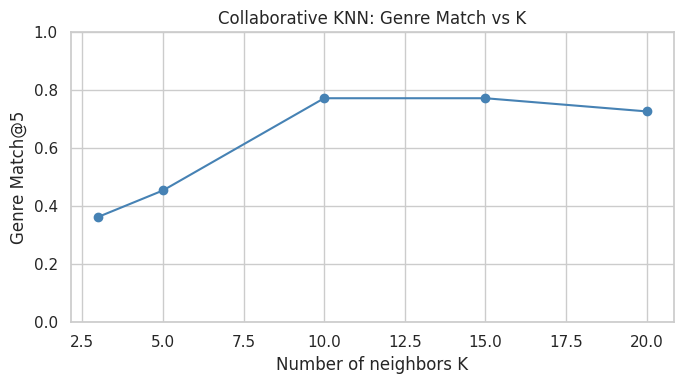

In [10]:
ks = [3, 5, 10, 15, 20]
genre_matches = []
for k in ks:
    m = CollabKNN(k_neighbors=k).fit(df, uf)
    def rec_fn(uid, excl, _m=m, _k=5):
        return _m.recommend(uid, top_k=_k)
    res = leave_one_out_eval(df, rec_fn, top_k=5)
    genre_matches.append(res['genre_match_at_k'])
    print(f'k_neighbors={k:2d}: genre_match@5={res["genre_match_at_k"]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, genre_matches, marker='o', color='steelblue')
ax.set_xlabel('Number of neighbors K')
ax.set_ylabel('Genre Match@5')
ax.set_title('Collaborative KNN: Genre Match vs K')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Part 4: Leave-one-out evaluation — Content vs Collab

In [11]:
TOP_K = 5

def content_rec(uid, excl):
    return content_model.recommend(uid, top_k=TOP_K)

def collab_rec(uid, excl):
    return collab_model.recommend(uid, top_k=TOP_K)

content_results = leave_one_out_eval(df, content_rec, top_k=TOP_K)
collab_results  = leave_one_out_eval(df, collab_rec,  top_k=TOP_K)

print('Content-based results:', content_results)
print('Collaborative results: ', collab_results)

Content-based results: {'hit_rate': 0.0, 'genre_match_at_k': 0.9545, 'precision_at_k': 0.0, 'recall_at_k': 0.0, 'n_users': 22}
Collaborative results:  {'hit_rate': 0.0, 'genre_match_at_k': 0.4545, 'precision_at_k': 0.0, 'recall_at_k': 0.0, 'n_users': 22}


## Part 5: K-means evaluation (for comparison)

In [12]:
scaler = StandardScaler()
scaled = scaler.fit_transform(jf.values)
k_range = range(2, 11)
inertias, sil_scores = elbow_analysis(scaled, k_range=k_range)
best_k = list(k_range)[int(np.argmax(sil_scores))]

km_model = KMeansRecommender(n_clusters=best_k).fit(df, jf)
kmeans_results = kmeans_genre_accuracy(
    df, km_model.recommend, uf, sf, top_k=1
)
print('K-means results:', kmeans_results)

K-means results: {'genre_accuracy': 0.1529, 'n_rows': 170}


## Part 6: Full comparison summary

In [13]:
print_comparison(content_results, collab_results, kmeans_results)

Metric                          Content KNN   Collab KNN K-means
---------------------------------------------------------------
genre_match_at_k (primary)           0.9545       0.4545  0.1529
---------------------------------------------------------------
hit_rate                             0.0000       0.0000     n/a
precision_at_k                       0.0000       0.0000     n/a
recall_at_k                          0.0000       0.0000     n/a
---------------------------------------------------------------
n evaluated                              22           22     170
Note: KNN hit_rate=0 is expected — 170 unique songs across 172 rows;
      almost no held-out song exists in another user's pool.
      Use genre_match_at_k as the primary comparison metric.


## Part 7: Bar chart comparison

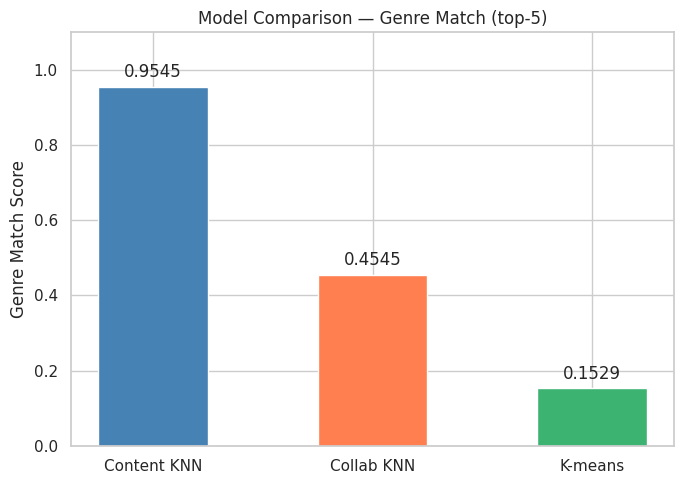

Note: KNN genre_match@K uses leave-one-out (n=22 users with ≥2 songs).
      K-means genre_accuracy is row-level (n=170 rows) — not directly comparable.


In [14]:
models = ['Content KNN', 'Collab KNN', 'K-means']
scores = [
    content_results['genre_match_at_k'],
    collab_results['genre_match_at_k'],
    kmeans_results['genre_accuracy'],
]
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, scores, color=colors, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_ylabel('Genre Match Score')
ax.set_title(f'Model Comparison — Genre Match (top-{TOP_K})')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('Note: KNN genre_match@K uses leave-one-out (n=22 users with ≥2 songs).')
print('      K-means genre_accuracy is row-level (n=170 rows) — not directly comparable.')

## Step 8

In [23]:
# Step 8: Handling Out-of-Vocabulary (OOV) Songs & Recommending
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def prep_feature_matrix(df, sf):
    """
    Ensures the song feature matrix uses actual song titles as the index,
    aggregating features for unique songs if necessary.
    """
    # Merge sf (row-wise features) with song names from df
    # reset_index(drop=True) on sf ensures alignment with df's index after selection
    sf_with_song_names = df[['song']].merge(sf.reset_index(drop=True), left_index=True, right_index=True)

    # Group by song name and average features to get unique song feature vectors
    sf_clean = sf_with_song_names.groupby('song').mean()

    sf_clean.index = sf_clean.index.astype(str)
    return sf_clean.select_dtypes(include='number')

def get_song_features(song_name, df, sf_numeric):
    """
    Retrieves song features. If not found, prompts the user for genre
    and imputes features using the genre mean.
    """
    song_name_str = str(song_name)

    # 1. Return existing features if present
    if song_name_str in sf_numeric.index:
        return sf_numeric.loc[song_name_str].to_frame().T

    print(f"[-] Song '{song_name}' not found in the dataset.")

    # 2. Prompt user for metadata
    valid_genres = df['genre'].dropna().unique()
    print(f"Available genres: {', '.join(valid_genres)}")

    user_genre = input("Enter the genre of the new song: ").strip()

    # 3. Impute via Global Mean (Fallback)
    if user_genre not in valid_genres:
        print("[!] Invalid genre. Imputing using global average features.")
        proxy_vector = sf_numeric.mean().to_frame().T
        proxy_vector.index = [song_name_str]
        return proxy_vector

    # 4. Impute via Genre Mean
    print(f"[+] Imputing features using the average of existing '{user_genre}' songs.")
    genre_songs = df[df['genre'] == user_genre]['song'].astype(str).unique()
    valid_genre_songs = [s for s in genre_songs if s in sf_numeric.index]

    if not valid_genre_songs:
        proxy_vector = sf_numeric.mean().to_frame().T
    else:
        proxy_vector = sf_numeric.loc[valid_genre_songs].mean().to_frame().T

    proxy_vector.index = [song_name_str]
    return proxy_vector

def recommend_similar_songs(song_name, df, sf, top_k=5):
    """
    Generates recommendations for a song by computing cosine similarity
    between its feature vector and all existing songs in the dataset.
    """
    # 1. Standardize sf to ensure it has song names as the index
    sf_numeric = prep_feature_matrix(df, sf)

    # 2. Get feature vector (handles OOV internally)
    song_vector = get_song_features(song_name, df, sf_numeric)

    # 3. Compute similarity against all known songs
    similarities = cosine_similarity(song_vector, sf_numeric)[0]
    sim_series = pd.Series(similarities, index=sf_numeric.index)

    # 4. Drop the input song itself from the results if it exists
    if str(song_name) in sim_series.index:
        sim_series = sim_series.drop(str(song_name))

    # 5. Extract Top K
    top_songs = sim_series.nlargest(top_k)

    # 6. Format output with metadata
    res = pd.DataFrame({'song': top_songs.index, 'similarity': top_songs.values})
    res['song'] = res['song'].astype(str)

    # subset=['song'] ensures we don't accidentally duplicate rows if there are conflicting metadata records
    metadata = df[['song', 'artist', 'genre', 'release_year']].drop_duplicates(subset=['song'])
    metadata['song'] = metadata['song'].astype(str)

    return res.merge(metadata, on='song', how='left')


# --- Testing ---
print("--- Testing OOV Song Recommendations ---")
test_new_song = "Fake Plastic Trees (Radiohead)"

recommendations = recommend_similar_songs(test_new_song, df, sf, top_k=5)

print(f"\nTop 5 Recommendations based on '{test_new_song}':")
print(recommendations)

--- Testing OOV Song Recommendations ---
[-] Song 'Fake Plastic Trees (Radiohead)' not found in the dataset.
Available genres: Pop, Indie / Alternative, Electronic / Dance, Hip Hop / Rap, Rock, Alternative Rock, K-pop, R&B / Soul, Mariachi, Classical, Country, Latin, Video Game Music, Jazz
Enter the genre of the new song: Rock
[+] Imputing features using the average of existing 'Rock' songs.

Top 5 Recommendations based on 'Fake Plastic Trees (Radiohead)':
                 song  similarity                 artist genre release_year
0  Friday I’m in Love    0.996052               The Cure  Rock    1980–1999
1        Hold My Hand    0.996052  Hootie & The Blowfish  Rock    1980–1999
2       No More Tears    0.996052          Ozzy Osbourne  Rock    1980–1999
3    Paranoid Android    0.996052              Radiohead  Rock    1980–1999
4   Island in the Sun    0.994373                 Weezer  Rock    2000–2009
